# <b>House Price Prediction</b>

## <b>Phase 8 – Model Comparison</b>

### <b>Objective</b>

Compare multiple regression algorithms using the same dataset and evaluation metrics.

Models:

- Linear Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- XGBoost

Evaluation:

- MAE
- MSE
- RMSE
- R² Score

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ( RandomForestRegressor, GradientBoostingRegressor )
from sklearn.metrics import ( mean_absolute_error, mean_squared_error, r2_score)
from xgboost import XGBRegressor

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [3]:
models = {

    "Linear Regression":
        LinearRegression(),

    "Decision Tree":
        DecisionTreeRegressor(
            random_state=42
        ),

    "Random Forest":
        RandomForestRegressor(
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            random_state=42
        ),
    
    "XGBoost":
        XGBRegressor(
            random_state=42
        )

}

In [4]:
results = []
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    predictions = model.predict(X_test)
    mae = mean_absolute_error(
        y_test,
        predictions
    )
    mse = mean_squared_error(
        y_test,
        predictions
    )
    rmse = np.sqrt(mse)
    r2 = r2_score(
        y_test,
        predictions
    )
    
    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })

In [5]:
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(
    by="R2 Score",
    ascending=False
)

comparison_df

,Model,MAE,MSE,RMSE,R2 Score
3,Gradient Boosting,9.605788e+05,1.689379e+12,1.299761e+06,0.665772
0,Linear Regression,9.700434e+05,1.754319e+12,1.324507e+06,0.652924
2,Random Forest,1.022197e+06,1.961944e+12,1.400694e+06,0.611848
4,XGBoost,1.073249e+06,2.099398e+12,1.448930e+06,0.584653
1,Decision Tree,1.195266e+06,2.642803e+12,1.625670e+06,0.477146


In [6]:
comparison_df.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

In [7]:
best_model_name = comparison_df.iloc[0]["Model"]
print(best_model_name)

Gradient Boosting


In [8]:
best_model = trained_models[best_model_name]
joblib.dump(
    best_model,
    "../models/best_model.pkl"
)

['../models/best_model.pkl']

In [9]:
for name, model in trained_models.items():
    filename = (
        name.lower()
            .replace(" ", "_")
            + "_model.pkl"
    )

    joblib.dump(
        model,
        "../models/" + filename
    )

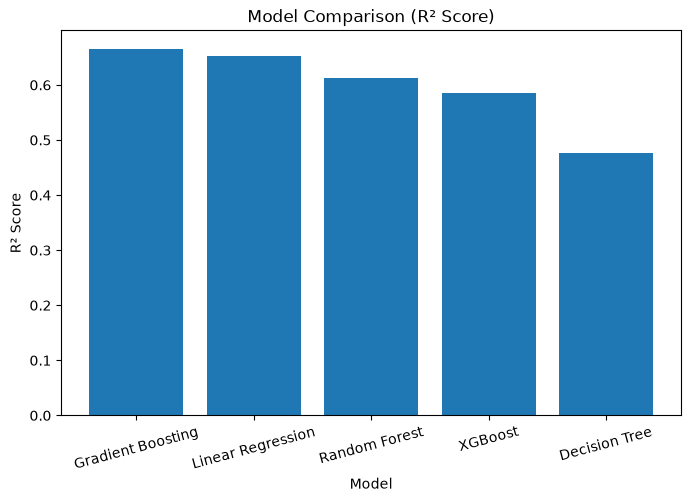

In [10]:
plt.figure(figsize=(8,5))
plt.bar(
    comparison_df["Model"],
    comparison_df["R2 Score"]
)
plt.title("Model Comparison (R² Score)")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=15)
plt.show()

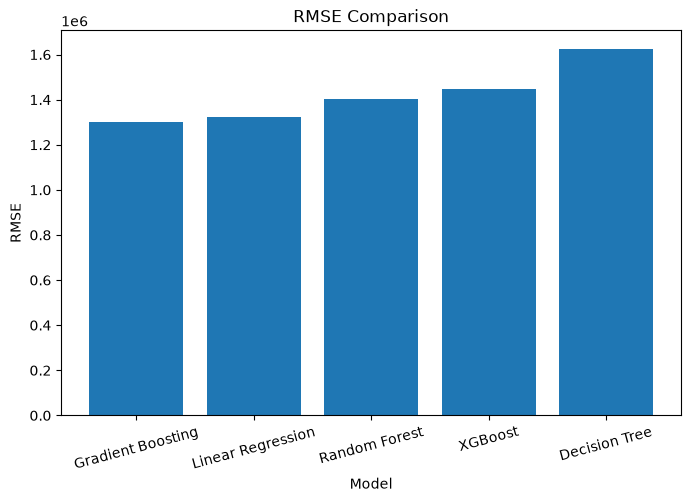

In [11]:
plt.figure(figsize=(8,5))
plt.bar(
    comparison_df["Model"],
    comparison_df["RMSE"]
)
plt.title("RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.show()

#### <b>Model Comparison Summary</b>

Models Evaluated:

- Linear Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- XGBoost (optional)

Evaluation Metrics:

- MAE
- MSE
- RMSE
- R² Score

The model with the highest R² score and the lowest prediction errors (MAE and RMSE) is selected as the best-performing model for deployment.